## Step 1: Generate Bimodal Toy Data

We'll create synthetic data where the target `y` has a **bimodal conditional distribution** given `x`:

- **Line 1**: `y = 2x + 5 + noise` (steep positive slope)
- **Line 2**: `y = -x + 15 + noise` (negative slope)

For each x value, y is randomly sampled from either line with probability 0.5, creating two distinct modes.

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

# ScoringBench imports
from scoringbench.wrappers import (
    TabICLWrapper,
    TabPFNWrapper,
    PytabkitRealMLPWrapper,
)
from scoringbench.metrics import compute_metrics

# Configure plotting
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [23]:
def generate_bimodal_data(n_samples=1000, seed=42):
    """
    Create a dataset with two distinct linear relationships plus noise.
    For each x value, y comes from one of two lines with equal probability.
    """
    np.random.seed(seed)
    
    m1, c1 = 2.0, 5.0      # Line 1: steep positive slope
    m2, c2 = -1.0, 15.0    # Line 2: negative slope
    noise_std = 2.0
    
    x = np.linspace(0, 10, n_samples)
    y1 = m1 * x + c1 + np.random.normal(0, noise_std, n_samples)
    y2 = m2 * x + c2 + np.random.normal(0, noise_std, n_samples)
    
    mask = np.random.binomial(1, 0.5, n_samples) == 1
    y = np.where(mask, y1, y2)
    
    return x.reshape(-1, 1), y


def visualize_bimodal_data(X, y, title="Bimodal Toy Data"):
    """Visualize the data with both true modes overlaid."""
    fig, ax = plt.subplots(figsize=(10, 6))
    
    x_vals = X.squeeze()
    ax.scatter(x_vals, y, alpha=0.4, s=20, label='Data points')
    
    x_plot = np.linspace(x_vals.min(), x_vals.max(), 100)
    y1_true = 2.0 * x_plot + 5.0
    y2_true = -1.0 * x_plot + 15.0
    ax.plot(x_plot, y1_true, 'r--', linewidth=2, label='True Mode 1')
    ax.plot(x_plot, y2_true, 'g--', linewidth=2, label='True Mode 2')
    
    ax.set_xlabel('x', fontsize=12)
    ax.set_ylabel('y', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    return fig

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

# ScoringBench imports
from scoringbench.wrappers import (
    TabICLWrapper,
    TabPFNWrapper,
    PytabkitRealMLPWrapper,
)
from scoringbench.metrics import compute_metrics

# Configure plotting
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

Generating bimodal toy dataset...
  ✓ Generated 1000 samples
  ✓ Train/test split: 800 / 200


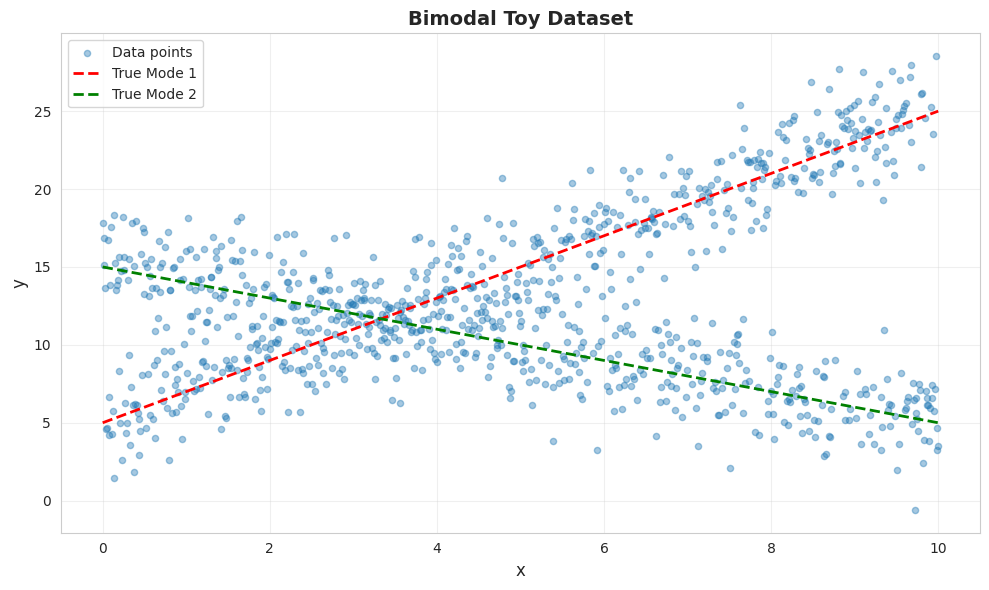

In [25]:
# Generate data
print("Generating bimodal toy dataset...")
X, y = generate_bimodal_data(n_samples=1000, seed=42)
print(f"  ✓ Generated {len(y)} samples")

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"  ✓ Train/test split: {len(y_train)} / {len(y_test)}")

# Visualize
fig_data = visualize_bimodal_data(X, y, title="Bimodal Toy Dataset")
plt.show()

## Step 2: Train Three Probabilistic Models

We'll train:
- **TabPFN**: Fast pretrained foundation model (no finetuning)
- **TabICL**: In-context learning approach
- **PyTabKit**: Fast neural tabular model with minimal training

Each model learns to predict a probability distribution over y rather than a single point estimate.

In [26]:
import torch
def train_models(X_train, y_train):
    """Train all three models. Returns dict of models."""
    print("\n" + "="*70)
    print("TRAINING MODELS")
    print("="*70)
    
    models = {}
    
    # TabPFN (Fast foundation model, no finetuning)
    print("\n[1/3] Training TabPFN (fast, pretrained)...")
    try:
        tabpfn_model = TabPFNWrapper(device="cpu")
        tabpfn_model.fit(X_train, y_train)
        models['TabPFN'] = tabpfn_model
        print("  ✓ TabPFN trained successfully")
    except Exception as e:
        print(f"  ✗ TabPFN failed: {str(e)[:60]}")
    
    # TabICL (In-context learning approach)
    print("\n[2/3] Training TabICL...")
    try:
        tabicl_model = TabICLWrapper()
        tabicl_model.fit(X_train, y_train)
        models['TabICL'] = tabicl_model
        print("  ✓ TabICL trained successfully")
    except Exception as e:
        print(f"  ✗ TabICL failed: {str(e)[:60]}")
    
    # PyTabKit (Fast neural tabular model)
    # print("\n[3/3] Training PyTabKit RealMLP (fast mode)...")
    # try:
    #     pytabkit_model = PytabkitRealMLPWrapper(
    #         n_epochs=10,
    #         device='cpu',
    #     )
    #     pytabkit_model.fit(X_train, y_train)
    #     models['PyTabKit'] = pytabkit_model
    #     print("  ✓ PyTabKit trained successfully")
    # except Exception as e:
    #     print(f"  ✗ PyTabKit failed: {str(e)[:60]}")
    
    return models

In [27]:
# Train the models
models = train_models(X_train, y_train)
print(f"\n✓ Successfully trained {len(models)} model(s)\n")


TRAINING MODELS

[1/3] Training TabPFN (fast, pretrained)...
  ✓ TabPFN trained successfully

[2/3] Training TabICL...


/home/landsges/.local/lib/python3.12/site-packages/tabpfn/validation.py:56: UserWarning: Running on CPU with more than 200 samples may be slow.
Consider using a GPU or the tabpfn-client API: https://github.com/PriorLabs/tabpfn-client
  _validate_num_samples_for_cpu(


  ✓ TabICL trained successfully

✓ Successfully trained 2 model(s)



## Step 3: Compare Conditional Distributions

For x=5.0, we'll compare:
1. **Actual data**: Histogram of y values near x=5.0
2. **Model predictions**: Probability mass functions (PMFs) predicted by each model

A good bimodal-aware model should predict **two distinct peaks**, matching the actual bimodal structure.

In [28]:
def plot_conditional_pmfs_at_x(models, X_test, y_test, x_value=9.0, x_tolerance=0.5):
    """
    For a specific x value, show the conditional PMF predicted by each model
    compared against the actual histogram of y values near that x.
    All histograms use common support (same x-axis range).
    """
    # Find test samples near x_value
    x_vals = X_test.squeeze()
    mask = np.abs(x_vals - x_value) <= x_tolerance
    y_nearby = y_test[mask]
    
    if len(y_nearby) == 0:
        print(f"Warning: No test samples near x={x_value}")
        y_nearby = y_test
    
    X_single = np.array([[x_value]])
    n_models = len(models)

    y_min=-2
    y_max=30

    # Use squeeze=False and extract row to properly handle axes
    fig, axes = plt.subplots(1, n_models + 1, figsize=(5 * (n_models + 1), 4), squeeze=False)
    axes = axes[0]
    
    # Plot 0: Actual data distribution (faster histogram)
    ax = axes[0]
    ax.hist(y_nearby, bins=15, alpha=0.7, color='gray', edgecolor='black', density=True)
    ax.set_xlabel('y', fontsize=10)
    ax.set_ylabel('Density', fontsize=10)
    ax.set_title(f'Actual Data (n={len(y_nearby)})', fontsize=10, fontweight='bold')
    ax.set_xlim(y_min, y_max)
    ax.grid(True, alpha=0.2)
    
    # Plot i: Model predicted PMFs
    for idx, (model_name, model) in enumerate(models.items()):
        ax = axes[idx + 1]
        
        try:
            dist = model.predict_distribution(X_single)
            probas = dist.probas[0]
            bin_edges = dist.bin_edges if dist.bin_edges.ndim == 1 else dist.bin_edges[0]
            bin_mids = dist.bin_midpoints if dist.bin_midpoints.ndim == 1 else dist.bin_midpoints[0]
            
            bin_widths = np.diff(bin_edges)
            ax.bar(bin_mids, probas / bin_widths, width=bin_widths * 0.9,
                   alpha=0.7, edgecolor='black', color='steelblue')
            
            mean_pred = dist.mean[0]
            ax.axvline(mean_pred, color='red', linestyle='--', linewidth=1.5, 
                      label=f'μ={mean_pred:.1f}')
            
            ax.set_xlabel('y', fontsize=10)
            ax.set_ylabel('Density', fontsize=10)
            ax.set_title(f'{model_name}', fontsize=10, fontweight='bold')
            ax.set_xlim(y_min, y_max)
            ax.legend(fontsize=9)
            ax.grid(True, alpha=0.2)
            
        except Exception as e:
            ax.text(0.5, 0.5, f'Error:\n{str(e)[:30]}', ha='center', va='center',
                   transform=ax.transAxes, fontsize=9, color='red')
            ax.set_title(f'{model_name} [FAILED]', fontsize=10)
    
    plt.tight_layout()
    return fig

CONDITIONAL DISTRIBUTIONS AT x=9.0
Comparing actual data vs predicted PMFs from each model



/tmp/ipykernel_20338/2117753190.py:46: RuntimeWarning: invalid value encountered in divide
  ax.bar(bin_mids, probas / bin_widths, width=bin_widths * 0.9,


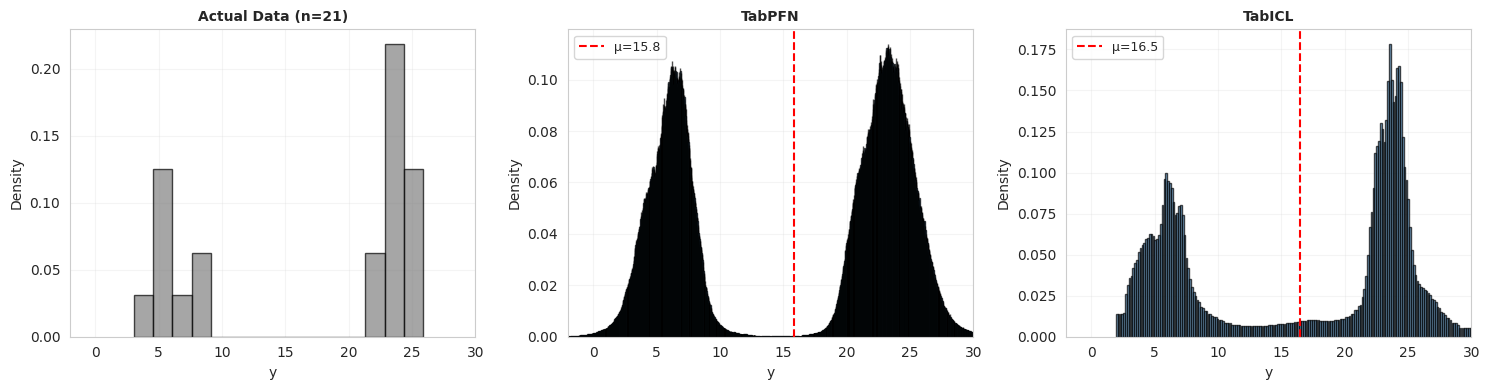

In [29]:
# Visualize conditional distributions at x=5.0
if models:
    x_value = 9.0
    print("="*70)
    print(f"CONDITIONAL DISTRIBUTIONS AT x={x_value}")
    print("="*70)
    print("Comparing actual data vs predicted PMFs from each model\n")
    
    fig_pmfs = plot_conditional_pmfs_at_x(models, X_test, y_test, x_value=x_value, x_tolerance=0.5)
    plt.show()

## Step 4: Evaluate and Compare Performance

We'll compute multiple metrics on the test set:
- **Point metrics** (MSE, RMSE, MAE): How accurate are point predictions?
- **Probabilistic metrics** (CRPS, log_score): How well does the distribution match reality?

In bimodal scenarios, CRPS should favor models that capture both modes correctly.

In [35]:
def evaluate_models(models, X_test, y_test):
    """Compute metrics for all models on the test set."""
    print("\n" + "="*70)
    print("EVALUATING MODELS ON TEST SET")
    print("="*70)
    
    results = []
    
    for model_name, model in models.items():
        print(f"\n{model_name}...")
        
        try:
            y_pred_point = model.predict(X_test)
            mse = mean_squared_error(y_test, y_pred_point)
            mae = mean_absolute_error(y_test, y_pred_point)
            rmse = np.sqrt(mse)
            
            try:
                dist = model.predict_distribution(X_test)
                metrics_dict = compute_metrics(dist, y_test)
                crps = metrics_dict.get('crps', np.nan)
                log_score = metrics_dict.get('log_score', np.nan)
                crls = metrics_dict.get('crls', np.nan)
            except Exception as score_error:
                print(f"  ⚠ Scoring rules failed: {str(score_error)[:80]}")
                crps = np.nan
                log_score = np.nan
                crls = np.nan
            
            results.append({
                'Model': model_name,
                'MSE': mse,
                'RMSE': rmse,
                'MAE': mae,
                'CRPS': crps,
                'log_score': log_score,
                'CRLS': crls,
            })
            
            print(f"  MSE:  {mse:.4f}")
            print(f"  RMSE: {rmse:.4f}")
            print(f"  MAE:  {mae:.4f}")
            if not np.isnan(crps):
                print(f"  CRPS: {crps:.4f}")
            if not np.isnan(crls):
                print(f"  CRLS: {crls:.4f}")
            
        except Exception as e:
            print(f"  ✗ Evaluation failed: {str(e)[:60]}")
    
    return pd.DataFrame(results)


In [36]:
evaluate_models(models, X_test, y_test)


EVALUATING MODELS ON TEST SET

TabPFN...
  MSE:  29.1021
  RMSE: 5.3946
  MAE:  4.4606
  CRPS: 2.7386
  CRLS: 8.2328

TabICL...
  MSE:  28.7426
  RMSE: 5.3612
  MAE:  4.4205
  CRPS: 2.7150
  CRLS: 8.1834


,Model,MSE,RMSE,MAE,CRPS,log_score,CRLS
0,TabPFN,29.102142,5.394640,4.460589,2.738616,2.634123,8.232807
1,TabICL,28.742634,5.361216,4.420503,2.715005,2.637242,8.183390


## Summary

In this notebook, we demonstrated how probabilistic models handle bimodal regression:

✓ **Data generation**: Created synthetic data with two distinct modes  
✓ **Model training**: Trained TabPFN, TabICL, and PyTabKit on the bimodal data  
✓ **Visualization**: Compared predicted distributions (should show two peaks!)  
✓ **Evaluation**: Measured performance using both point and probabilistic metrics  

**Key finding**: Models trained to capture distributions (CRPS) should outperform models optimizing only point predictions when the data exhibits multimodal behavior.